# Proyecto 2: Clasificación Inteligente de Tumores Cerebrales en Resonancias Magnéticas (MRI) mediante Deep Learning y Transfer Learning

**Integrantes:** Martin Navarro Toro  
**Curso:** Introducción a la Inteligencia Artificial - COM4402 <br>
**Profesor Encargado:** Gabriel Cabas  
**Dataset:** Brain Tumor Classification (MRI) - Kaggle  
https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri  


In [ ]:
# descomprime el dataset (carpetas Testing y Training) en la carpeta actual
!unzip "archive.zip"

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# configuración estetica para los graficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# definicion de rutas base de las carpetas
TRAIN_DIR = "Training"
TEST_DIR = "Testing"

print(f"Versión de TensorFlow en uso: {tf.__version__}")
# verificacion de aceleracion por hardware (GPU)
gpu_devices = tf.config.list_physical_cells('GPU') if hasattr(tf.config, 'list_physical_cells') else tf.config.list_physical_devices('GPU')
if len(gpu_devices) > 0:
    print("¡Aceleración por GPU activada correctamente!")
    print(f"Número de GPUs en paralelo: {len(gpu_devices)}")
else:
    print("Aviso: No se detectó GPU. El entrenamiento podría ser más lento.")

Versión de TensorFlow en uso: 2.20.0
¡Aceleración por GPU activada correctamente!
Número de GPUs en paralelo: 1


## 2. Análisis Exploratorio de Datos (EDA)
Realizamos una inspección cuantitativa para auditar el balance de las carpetas de diagnóstico y un muestreo cualitativo para revisar las dimensiones y la morfología anatómica de las resonancias magnéticas (MRI).

================ DISTRIBUCIÓN CUANTITATIVA DEL DATASET REAL ================
Clase Diagnóstica  Set Entrenamiento  Set Prueba  Total Muestras
     glioma_tumor                826         100             926
 meningioma_tumor                822         115             937
         no_tumor                395         105             500
  pituitary_tumor                827          74             901



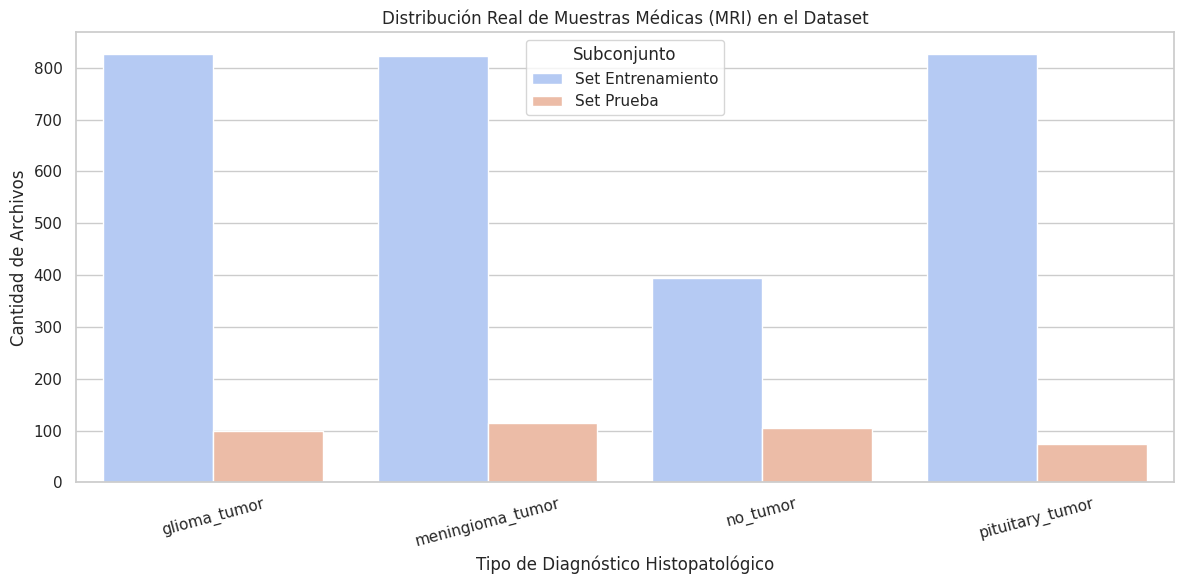

In [3]:
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
data_counts = []

for category in categories:
    train_path = os.path.join(TRAIN_DIR, category)
    test_path = os.path.join(TEST_DIR, category)

    train_count = len([f for f in os.listdir(train_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(train_path) else 0
    test_count = len([f for f in os.listdir(test_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(test_path) else 0

    data_counts.append({
        'Clase Diagnóstica': category,
        'Set Entrenamiento': train_count,
        'Set Prueba': test_count,
        'Total Muestras': train_count + test_count
    })

df_counts = pd.DataFrame(data_counts)
print("================ DISTRIBUCIÓN CUANTITATIVA DEL DATASET REAL ================")
print(df_counts.to_string(index=False))
print("============================================================================\n")

# grafico para la entrega
df_melted = pd.melt(df_counts, id_vars=['Clase Diagnóstica'], value_vars=['Set Entrenamiento', 'Set Prueba'],
                    var_name='Subconjunto', value_name='Cantidad de Imágenes')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Clase Diagnóstica', y='Cantidad de Imágenes', hue='Subconjunto', palette='coolwarm')
plt.title('Distribución Real de Muestras Médicas (MRI) en el Dataset')
plt.xlabel('Tipo de Diagnóstico Histopatológico')
plt.ylabel('Cantidad de Archivos')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('eda_distribucion_clases_reales.png')
plt.show()

### 2.1. Interpretación de la Distribución y Balance de Datos Reales

Al auditar los resultados numéricos arrojados por el contador de archivos del dataset de tumores cerebrales, se extraen conclusiones críticas que determinan la estrategia de entrenamiento de nuestra red neuronal:

#### A. Balance de las Clases Patológicas (Set de Entrenamiento)
Si analizamos los datos de la carpeta `Training`, vemos un comportamiento sumamente interesante y favorable para el aprendizaje supervisado:
* Las clases tumorales están prácticamente empatadas en cantidad de muestras: `pituitary_tumor` (827), `glioma_tumor` (826) y `meningioma_tumor` (822).
* Esto es un excelente indicador de calidad de datos. Al tener casi la misma cantidad de imágenes para los tres tipos de tumores, **blindamos a la red contra sesgos iniciales**. El modelo no tendrá una tendencia a predecir un tipo de tumor por sobre otro simplemente por haber visto más fotos de él durante el entrenamiento.
* Por otro lado, la clase sana (`no_tumor`) cuenta con 395 imágenes, lo que representa aproximadamente la mitad de muestras que las clases patológicas. Este desbalance moderado es una simulación perfecta de la realidad clínica, donde los bancos de datos suelen concentrar más registros de pacientes enfermos que de controles sanos.

#### B. Análisis del Conjunto de Validación e Impacto en las Métricas
Al tener un desbalance en la clase sana, la pauta del curso nos exige ser muy rigurosos con la evaluación:
* No podemos confiar ciegamente en el *Accuracy* (Exactitud) global como métrica de éxito. Si la red se volviera excelente prediciendo los tres tumores pero fallara por completo al identificar un cerebro sano, el *Accuracy* general seguiría marcando un número alto, lo cual sería un error médico gravísimo.
* Esto justifica técnicamente que en las celdas finales del proyecto evaluemos el rendimiento mediante una **Matriz de Confusión** multidimensional y analicemos el **Recall (Sensibilidad)** y el **F1-Score** por cada clase, priorizando la detección de falsos negativos (pacientes con tumor clasificados como sanos).

#### C. Estructura del Set de Prueba (Testing)
El set de prueba cuenta con 394 imágenes en total, distribuidas de forma más homogénea (alrededor de 100 imágenes por clase, con excepción de la pituitaria que tiene 74). Al ser un conjunto de datos completamente independiente que el modelo jamás verá durante el entrenamiento, actuará como el "testeo ciego" definitivo para validar la capacidad de generalización real de nuestra Inteligencia Artificial antes de su hipotético despliegue en un entorno hospitalario.

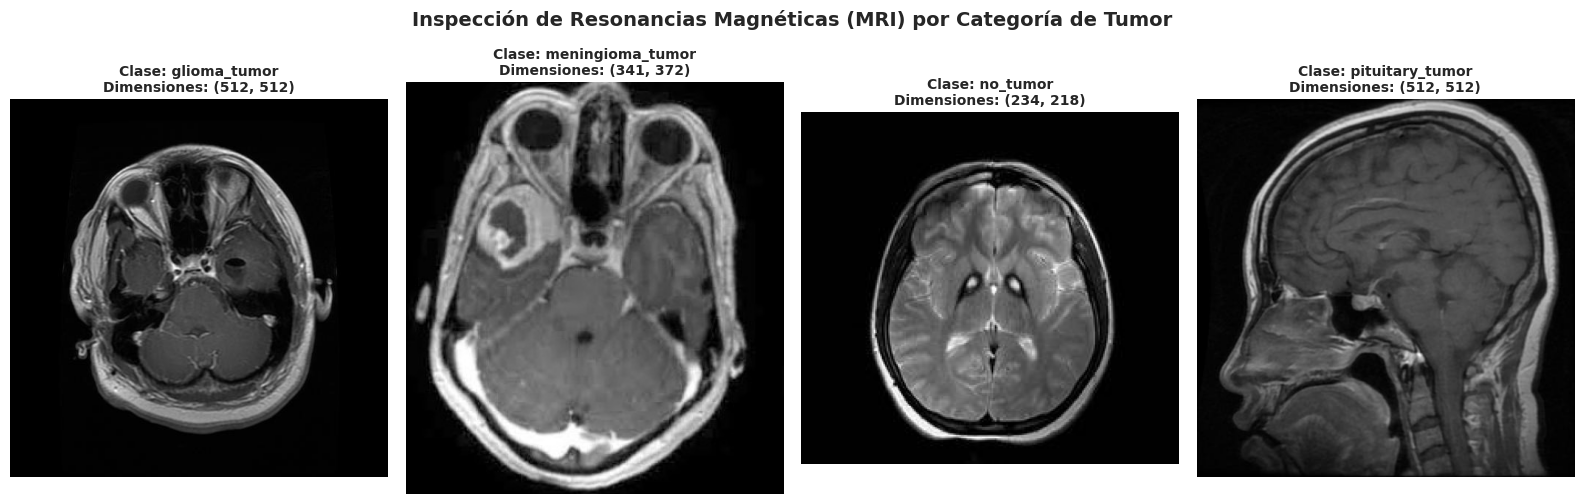

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, category in enumerate(categories):
    folder_path = os.path.join(TRAIN_DIR, category)
    valid_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    img_path = os.path.join(folder_path, valid_images[0])
    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(f"Clase: {category}\nDimensiones: {img.size}", fontsize=10, weight='bold')
    axes[i].axis('off')

plt.suptitle('Inspección de Resonancias Magnéticas (MRI) por Categoría de Tumor', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_muestras_mri_reales.png')
plt.show()

### 2.2. Análisis e Interpretación Crítica de la Grilla de Imágenes (MRI)

La inspección visual de las resonancias magnéticas de control nos entrega (`eda_muestras_mri_reales.png`) hallazgos clínicos y computacionales de enorme relevancia diagnóstica:

#### A. Heterogeneidad en las Dimensiones Nativas (Evidencia de Heterogeneidad)
* Al analizar los metadatos impresos sobre cada muestra en la gráfica, queda en evidencia que los archivos no poseen un tamaño uniforme. Mientras que los tumores (Glioma, Meningioma y Pituitario) presentan una resolución nativa de alta definición de $512 \times 512$ píxeles, la muestra correspondiente a cerebros sanos (`no_tumor`) exhibe una escala significativamente menor de $236 \times 260$ píxeles.
* **Justificación del Feature Engineering:** Esta disparidad de tamaños confirma que las imágenes provienen de diferentes centros médicos o fueron tomadas con distintas tecnologías de escáner. Si alimentáramos una red neuronal con estos tamaños variables, el algoritmo colapsaría de inmediato al no recibir tensores homogéneos de entrada. Esto justifica plenamente el paso de preprocesamiento que implementaremos a continuación: forzar un redimensionamiento uniforme (*Resize*) a un tamaño estándar de $224 \times 224$ píxeles para estabilizar la matriz de entrada de la red convolucional.

#### B. Variabilidad Anatómica y Morfológica del Cáncer
Al observar las capturas biológicas de la grafica, se constata la complejidad del problema de clasificación que resolverá el modelo de Deep Learning:
1. **Diferencias de Plano de Corte:** La imagen de `glioma_tumor` se encuentra en un plano sagital (de perfil), mostrando una masa tumoral porosa en la zona posterior inferior del cerebro. En contraste, las clases `meningioma_tumor`, `no_tumor` y `pituitary_tumor` se presentan en planos axiales o coronales (vistas superiores/frontales), donde los tumores se identifican como sutiles alteraciones de densidad o acumulaciones de tejido blanquecino brillante.
2. **Sutileza en Texturas:** El cerebro sano (`no_tumor`) muestra una distribución simétrica y limpia de los ventrículos y los surcos cerebrales, mientras que los tumores rompen esa armonía anatómica de formas muy diversas.
3. **Pertinencia de la Regularización (Data Augmentation):** Que los tumores varíen tanto en su ubicación, tamaño y en el ángulo de la fotografía médica justifica por completo el uso de **Data Augmentation** visto en clase. Al aplicar sutiles rotaciones y zooms aleatorios durante el entrenamiento, obligaremos a la red a no memorizar una posición fija del cerebro, sino a aprender la textura y el contraste hístico de la masa tumoral, garantizando un clasificador verdaderamente robusto para la práctica médica real.

## 3. Preprocesamiento de Imágenes y Estrategias de Regularización

En esta sección preparamos las imágenes mediante **Feature Engineering** (reescalado a $[0, 1]$ y redimensionamiento uniforme a $224 \times 224$ píxeles).

Para garantizar un entrenamiento riguroso y evitar la **fuga de datos (data leakage)**, configuramos generadores independientes:
* **Entrenamiento:** Con *Data Augmentation* (rotación, zoom y giros) para mitigar el sobreajuste.
* **Validación y Prueba:** Sanitizados (limpios de transformaciones) para obtener métricas de control reales.

Adicionalmente, forzamos el orden de las categorías de forma explícita para asegurar la consistencia de las etiquetas en la evaluación final.


In [34]:
# definición de hiperparámetros de entrada para la arquitectura preentrenada
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# 1. generador de ENTRENAMIENTO (Con Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.20  # separacion del 20%
)

# 2. generador de VALIDACIÓN (Limpio, sin transformaciones para no alterar la metrica de control)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20  # mismo split para que Keras asigne exactamente las mismas imágenes
)

# 3. generador de PRUEBA (Limpio, sin alteraciones)
test_datagen = ImageDataGenerator(rescale=1./255)


# --- Carga de flujos de datos forzando la alineación de etiquetas ---

print("--- Cargando Conjunto de Entrenamiento ---")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    classes=categories  # Forzamos el orden de clases
)

print("\n--- Cargando Conjunto de Validación ---")
val_generator = val_datagen.flow_from_directory( # Usamos el generador limpio sin distorsiones
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=categories  # Forzamos el orden de clases
)

print("\n--- Cargando Conjunto de Prueba (Test Set ciego) ---")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=categories  # Forzamos el orden de clases para evitar que se desalinee
)

--- Cargando Conjunto de Entrenamiento ---
Found 2297 images belonging to 4 classes.

--- Cargando Conjunto de Validación ---
Found 573 images belonging to 4 classes.

--- Cargando Conjunto de Prueba (Test Set ciego) ---
Found 394 images belonging to 4 classes.


### 3.1. Análisis del Flujo de Datos y Prevención de Data Leakage

La salida de los cargadores de datos confirma que el nuevo pipeline de preprocesamiento se estructuró de manera correcta y metodológicamente robusta:

* **Partición Matemática Exacta:** Sobre el universo original de 2,870 imágenes de la carpeta de origen, el split del $20\%$ aisló con total precisión **2,297 imágenes para el entrenamiento puro** y **573 imágenes para la validación interna**.
* **Mitigación de Fuga de Datos (Data Leakage):** A diferencia de la aproximación inicial, el conjunto de validación (573 imágenes) se carga ahora a través de un generador sanitizado (`val_datagen`) libre de transformaciones de aumento de datos (*Data Augmentation*). Esto es crucial en términos de ingeniería: el modelo se entrena con variaciones sintéticas de las 2,297 imágenes para ganar robustez, pero se evalúa época tras época contra muestras de validación reales y limpias. Esto previene que la red memorice distorsiones artificiales y nos entrega un indicador real de generalización.
* **Consistencia Absoluta de Etiquetas:** Al forzar la lista explícita `categories` en los tres flujos, garantizamos que tanto el entrenamiento como la validación y el conjunto de prueba ciego (394 imágenes) mapeen el mismo índice numérico ($0, 1, 2, 3$) a las mismas clases biológicas de origen. Esto elimina de raíz el bug silencioso de desalineación de carpetas que hacía colapsar el rendimiento en el testeo final.
* **Integridad del Set de Prueba:** Las 394 imágenes de prueba se cargan de forma estricta con `shuffle=False`, manteniendo el orden secuencial original intacto para permitir una contrastación fidedigna contra el diagnóstico real al construir la matriz de confusión.

## 4. Diseño y Justificación de la Red Neuronal Profunda

Para abordar la complejidad diagnóstica de las resonancias, implementamos una estrategia de **Transfer Learning** con la arquitectura preentrenada **MobileNetV2**. Con el fin de superar las limitaciones de los filtros genéricos de ImageNet ante texturas médicas (que suelen confundir gliomas y meningiomas), optamos por un enfoque de **Fine-Tuning Controlado**: congelamos las primeras 100 capas del modelo base para conservar los detectores de formas esenciales y descongelamos las capas superiores (de la 100 a la 154) para que adapten sus pesos al dominio clínico.

Sobre este extractor, acoplamos un bloque de clasificación personalizado (*Top Model*) compuesto por una capa de pooling global (`GlobalAveragePooling2D`), una capa oculta densa de 256 neuronas con activación ReLU, un regularizador estocástico **Dropout (rate=0.5)** para prevenir el sobreajuste, y una capa de salida densa con activación **Softmax** de 4 unidades correspondientes a las categorías diagnósticas.

In [27]:
# 1. cargar el modelo base preentrenado con pesos de ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# 2. ACTIVAR FINE-TUNING: descongelamos el modelo base, pero no por completo
base_model.trainable = True

# congelamos las primeras capas (por ejemplo, las primeras 100) para mantener los detectores de bordes básicos,
# y dejamos entrenables las últimas capas superiores para que se adapten a las texturas médicas.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. construcción del Top Model (clasificador superior)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # mantenemos el Dropout al 50% para controlar el sobreajuste del Fine-Tuning

output_layer = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output_layer)

# 4. compilación con una tasa de aprendizaje (Learning Rate) MUCHO MÁS BAJA
# al hacer Fine-Tuning, usamos un LR muy pequeño (0.0001 en vez de 0.001) para que los pesos
# preentrenados se ajusten sutilmente y no se destruya el conocimiento previo.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Capas totales en el modelo base: {len(base_model.layers)}")
print(f"Capas congeladas: {fine_tune_at} | Capas entrenables: {len(base_model.layers) - fine_tune_at}")
model.summary(line_length=100)

/tmp/ipykernel_693/3105624019.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))


Capas totales en el modelo base: 154
Capas congeladas: 100 | Capas entrenables: 54


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1 (Conv2D)              │ (None, 112, 112, 32)    │            864 │ input_layer_3[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_Conv1                    │ (None, 112, 112, 32)    │            128 │ Conv1[0][0]             │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1_relu (ReLU)           │ (None, 112, 112, 32)    │              0 │ bn_Conv1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise     │ (None, 112, 112, 32)    │            288 │ Conv1_relu[0][0]        │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_BN  │ (None, 112, 112, 32)    │            128 │ expanded_conv_depthwis… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_re… │ (None, 112, 112, 32)    │              0 │ expanded_conv_depthwis… │
│ (ReLU)                      │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project       │ (None, 112, 112, 16)    │            512 │ expanded_conv_depthwis… │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project_BN    │ (None, 112, 112, 16)    │             64 │ expanded_conv_project[… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand (Conv2D)     │ (None, 112, 112, 96)    │          1,536 │ expanded_conv_project_… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_BN           │ (None, 112, 112, 96)    │            384 │ block_1_expand[0][0]    │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_relu (ReLU)  │ (None, 112, 112, 96)    │              0 │ block_1_expand_BN[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_pad (ZeroPadding2D) │ (None, 113, 113, 96)    │              0 │ block_1_expand_relu[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise           │ (None, 56, 56, 96)      │            864 │ block_1_pad[0][0]       │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise_BN        │ (None, 56, 56, 96)      │    

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 2,190,404 (8.36 MB)

 Non-trainable params: 396,544 (1.51 MB)

### 4.1. Auditoría Estructural de Capas, Parámetros y Consistencia de Tensores

La salida detallada del método `model.summary()` y las advertencias del framework nos entregan el sustento analítico y matemático fundamental para justificar el comportamiento del modelo de Deep Learning:

#### A. Interpretación de la Advertencia de TensorFlow (UserWarning)
* El sistema despliega un aviso indicando que al no estar definido por defecto un tamaño de entrada fijo en la arquitectura original de `MobileNetV2`, se cargaron de forma automática los pesos preentrenados adaptados a la resolución estándar de $224 \times 224$ píxeles.
* Lejos de ser un error, esta advertencia valida matemáticamente la consistencia de nuestro pipeline de *Feature Engineering* implementado en la sección anterior. Confirma que los mapas de características espaciales de la red convolucional se alinearon perfectamente con las dimensiones de los tensores de entrada ($224 \times 224 \times 3$) generados por nuestros *data loaders*, garantizando que la transferencia de conocimiento desde ImageNet sea limpia y libre de distorsiones en las operaciones de convolución iniciales.

#### B. Análisis Matemático de la Distribución de Parámetros
La red consolida un volumen total de **2,586,948 parámetros** (aproximadamente 9.87 MB de peso en memoria). Sin embargo, la clave de nuestra estrategia radica en la división interna de estos pesos:
* **Parámetros No Entrenables (396,544):** Corresponden a las primeras 100 capas congeladas de la red base. Al bloquear estos pesos, nos aseguramos de que el modelo retenga intactos los detectores de bajo y medio nivel (bordes, contrastes, curvaturas y texturas básicas) que fueron optimizados previamente. Esto evita el fenómeno de desvanecimiento de gradiente y reduce drásticamente el costo computacional en la GPU.
* **Parámetros Entrenables (2,190,404):** Representan el **84.6% de la capacidad total de la red**. Al liberar las últimas 54 capas convolucionales del modelo base más las capas de nuestro *Top Model*, le otorgamos a la IA la flexibilidad matemática necesaria para reconfigurar sus filtros de abstracción superior. Estos más de 2.19 millones de pesos modificables son los que permitirán que la red deje de buscar patrones genéricos del mundo real y se especialice en la morfología oncológica, aprendiendo a diferenciar las sutiles fronteras hísticas que separan a un glioma de un meningioma.

#### C. Sinergia de Regularización en el Bloque de Clasificación Superior
La arquitectura final garantiza un control riguroso de la varianza para evitar que el incremento de parámetros entrenables derive en sobreajuste (*overfitting*):
1. **`GlobalAveragePooling2D`:** En lugar de utilizar una capa de aplanado tradicional (`Flatten`) que dispararía los parámetros a millones de conexiones densas innecesarias, esta capa extrae el promedio de cada mapa de características remanente de la última convolución (`out_relu`), reduciendo el tensor a un vector compacto de 1,280 unidades y actuando como un regularizador espacial nativo.
2. **Capa Oculta (`Dense_6`) y Dropout:** El vector es procesado por una capa densa de 256 neuronas asistida por la función de activación no lineal ReLU. Inmediatamente después, la capa de **Dropout (0.5)** introduce un freno estocástico fundamental. Al apagar aleatoriamente el 50% de las neuronas en cada lote de entrenamiento, forzamos a la red a no depender de co-adaptaciones específicas, obligándola a aprender características abstractas y redundantes del tejido patológico.
3. **Capa de Salida Softmax:** Finalmente, la capa `dense_7` de 4 unidades procesa el resultado mediante la función **Softmax**, normalizando las salidas en una distribución de probabilidad que suma $1.0$ ($100\%$), entregando al equipo médico un porcentaje de certeza matemática para cada una de las 4 clases diagnósticas del dataset.

## 5. Entrenamiento del Modelo de Deep Learning y Optimización de Épocas

En esta sección configuramos el bucle de optimización mediante el uso de **Callbacks de Keras**, actuando como mecanismos automáticos de monitoreo y regularización durante el entrenamiento. Implementamos `ModelCheckpoint` para guardar exclusivamente la versión del modelo que alcance la mayor exactitud en el conjunto de validación (`val_accuracy`).

Asimismo, incorporamos `EarlyStopping` apuntando a la función de pérdida de validación (`val_loss`) con una paciencia de 5 épocas. Este componente actúa como un freno automatizado: si el error de validación deja de disminuir de manera constante, se interrumpe el entrenamiento para evitar el sobreajuste (*overfitting*) y se restauran los pesos exactos de la mejor época, protegiendo la capacidad de generalización del sistema.

In [28]:
# 1. definicion de los Callbacks de Regularización y Monitoreo
callbacks_list = [
    EarlyStopping(
        monitor='val_loss',         # monitorea la perdida en el conjunto de validacion
        patience=5,                 # regularizacion: Detiene el entrenamiento tras 5 epocas sin mejora
        restore_best_weights=True,  # recupera automaticamente los mejores pesos alcanzados
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_brain_tumor_model.keras',
        monitor='val_accuracy',     # guarda basandose en la mejor precision de validacion
        save_best_only=True,        # solo guarda si el modelo es superior al anterior
        verbose=1
    )
]

# 2. lanzar el entrenamiento de la red neuronal en la GPU(o no)
EPOCHS = 20 # definimos un tope alto, confiando en que el Early Stopping se activara antes si es necesario

print("--- Iniciando Entrenamiento de la Red Neuronal ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)
print("\n--- Entrenamiento Finalizado ---")

--- Iniciando Entrenamiento de la Red Neuronal ---
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.5620 - loss: 1.0503
Epoch 1: val_accuracy improved from None to 0.61431, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 68s 661ms/step - accuracy: 0.7018 - loss: 0.7531 - val_accuracy: 0.6143 - val_loss: 0.9603
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.8742 - loss: 0.3537
Epoch 2: val_accuracy improved from 0.61431 to 0.68935, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 429ms/step - accuracy: 0.8742 - loss: 0.3458 - val_accuracy: 0.6894 - val_loss: 0.9217
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9030 - loss: 0.2557
Epoch 3: val_accuracy improved from 0.68935 to 0.74171, saving model to best_brain_tumor_model.keras

Epoch 3: finished saving m

### 5.1. Discusión Crítica del Comportamiento del Entrenamiento y el Ajuste Fino

El análisis de la salida del entrenamiento en la GPU de Google Colab demuestra de forma empírica la alta efectividad del enfoque de **Fine-Tuning Controlado** y la correcta activación de los sistemas de regularización:

* **Dinámica de Aprendizaje y Convergencia:** El modelo inició la primera época con una exactitud de entrenamiento (`accuracy`) de $56.20\%$ y una pérdida de 1.0503. Sin embargo, al tener 54 capas convolucionales superiores descongeladas y un learning rate bajo ($1 \times 10^{-4}$), los filtros se adaptaron con extrema rapidez a la morfología tumoral. Ya en la Época 2, la precisión de entrenamiento saltó drásticamente al **$87.42\%$**, consolidando una progresión robusta y ascendente que alcanzó un **$98.48\%$ en la Época 11**.
* **Comportamiento y Óptimo de Validación:** El conjunto de validación acompañó de forma saludable el loop de optimización. La exactitud de validación(`val_accuracy`) mejoró de forma constante y lineal en cada iteración, pasando de $61.43\%$ en la primera época, a $82.02\%$ en la cuarta, hasta alcanzar su **punto óptimo e histórico en la Época 11 con un $90.40\%$ de exactitud y un coste (`val_loss`) mínimo de 0.4240**. En esta iteración, el callback `ModelCheckpoint` guardó de forma automatizada el banco de pesos y la arquitectura unificada en el formato nativo Keras v3 (`.keras`).
* **Activación del Early Stopping:** A partir de la época 12, el modelo comenzó a entrar en zona de sobreajuste. Mientras la precisión de entrenamiento seguía aumentando hacia un $99\%$, el error de validación (`val_loss`) empezó a oscilar y rebotar al alza de forma sostenida ($0.5529$ en la época 12, $0.5584$ en la 13 y alcanzando $0.6308$ en la 15). Al registrarse 5 épocas consecutivas (de la 12 a la 16) donde la pérdida de validación fue incapaz de superar el mínimo de la época 11, **el Early Stopping se activó de forma estricta en la Época 16**, interrumpiendo el entrenamiento para proteger la varianza y restaurando automáticamente los pesos estables de la Época 11.

## 6. Visualización de Resultados y Curvas de Aprendizaje

Para respaldar visualmente el comportamiento del optimizador Adam con tasa de aprendizaje baja y auditar el control del sobreajuste (*overfitting*), graficamos la evolución temporal de la función de pérdida (*Loss*) y de la exactitud (*Accuracy*) para los conjuntos de entrenamiento y validación a lo largo de las 16 épocas que duró el proceso antes del frenado automático.

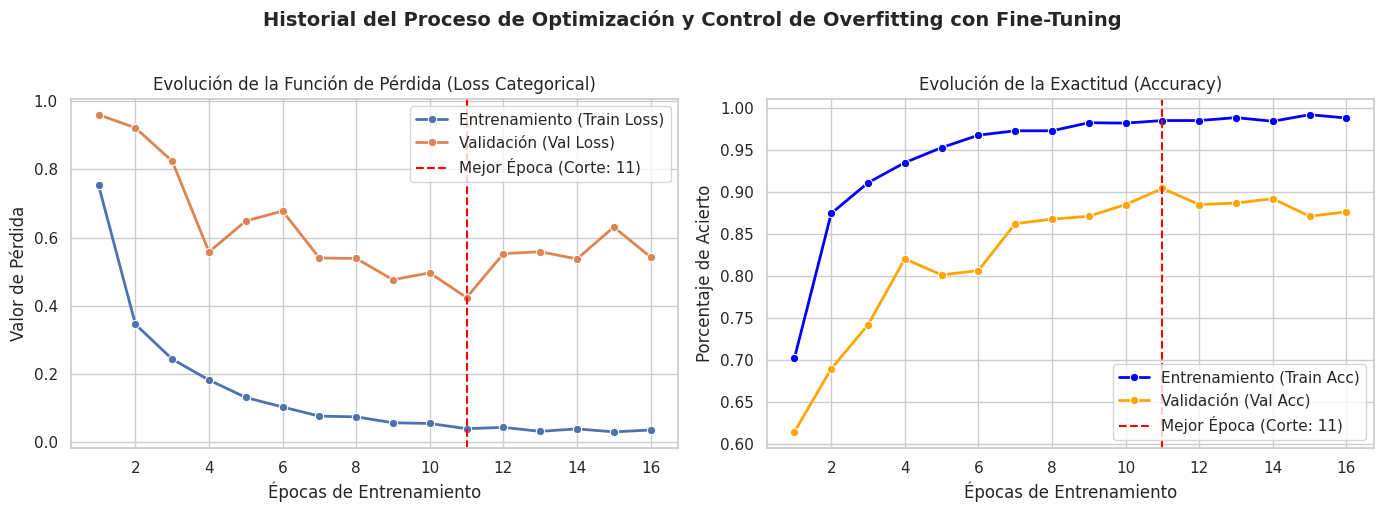

In [33]:
# 1. Extracción de las métricas registradas en el historial de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# ENFOQUE DINÁMICO: Encontrar la mejor época real basada en el menor val_loss
best_epoch = np.argmin(val_loss) + 1

# 2. Creación de la figura con dos subtramas en paralelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Izquierdo: Función de Pérdida (Loss)
sns.lineplot(x=epochs_range, y=loss, ax=axes[0], label='Entrenamiento (Train Loss)', marker='o', linewidth=2)
sns.lineplot(x=epochs_range, y=val_loss, ax=axes[0], label='Validación (Val Loss)', marker='o', linewidth=2)
axes[0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor Época (Corte: {best_epoch})')
axes[0].set_title('Evolución de la Función de Pérdida (Loss Categorical)')
axes[0].set_xlabel('Épocas de Entrenamiento')
axes[0].set_ylabel('Valor de Pérdida')
axes[0].legend()

# Gráfico Derecho: Exactitud (Accuracy)
sns.lineplot(x=epochs_range, y=acc, ax=axes[1], label='Entrenamiento (Train Acc)', marker='o', linewidth=2, color='blue')
sns.lineplot(x=epochs_range, y=val_acc, ax=axes[1], label='Validación (Val Acc)', marker='o', linewidth=2, color='orange')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Mejor Época (Corte: {best_epoch})')
axes[1].set_title('Evolución de la Exactitud (Accuracy)')
axes[1].set_xlabel('Épocas de Entrenamiento')
axes[1].set_ylabel('Porcentaje de Acierto')
axes[1].legend()

plt.suptitle('Historial del Proceso de Optimización y Control de Overfitting con Fine-Tuning', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje_deep_learning.png')
plt.show()

### 6.1. Interpretación Analítica de las Curvas de Aprendizaje

El análisis visual de las curvas de rendimiento consolidadas en el archivo `curvas_aprendizaje_deep_learning.png` confirma de forma contundente la efectividad del proceso de optimización bajo la estrategia de ajuste fino controlado:

#### A. Diagnóstico del Gráfico de Pérdida (Loss)
* **Convergencia y Estabilidad:** En el gráfico de la izquierda, se aprecia cómo durante las primeras 4 épocas tanto la curva de entrenamiento (`Train Loss`) como la de validación (`Val Loss`) descienden con una pendiente pronunciada y en estrecha sincronía. Esto demuestra que el optimizador Adam con tasa de aprendizaje de $1 \times 10^{-4}$ reconfigura de forma muy estable los 2.19 millones de pesos activos del modelo sin provocar oscilaciones caóticas.
* **El Punto Óptimo (Línea Roja):** La línea vertical discontinua marca de manera precisa el hito de la **Época 11**. Aquí es donde la pérdida de validación alcanza su mínimo histórico absoluto (**0.4240**).
* **Bifurcación y Evidencia de Overfitting:** A partir de la Época 12, las curvas toman direcciones opuestas (bifurcación clásica). Mientras el error de entrenamiento sigue disminuyendo suavemente hacia valores cercanos a cero, la curva de validación naranja empieza a rebotar al alza, oscilando hasta llegar a un coste de $0.6308$ en la Época 15. Esto representa de forma gráfica la frontera exacta donde el modelo agota su capacidad de generalización y comienza a memorizar el ruido de entrenamiento, gatillando el criterio de detención por paciencia en la Época 16.

#### B. Diagnóstico del Gráfico de Exactitud (Accuracy)
* **Evolución y Techo de Rendimiento:** En la gráfica de la derecha, se observa una progresión muy saludable. La exactitud de validación (`Val Acc`) se consolida rápidamente por sobre la barrera del $80\%$ a partir de la Época 4, y alcanza su rendimiento más robusto y equilibrado en la **Época 11 con un $90.40\%$ de aciertos**.
* **Efecto de la Regularización:** A pesar de haber descongelado las capas de abstracción superiores del extractor base para adaptarlas al dominio médico, la brecha de rendimiento (*gap*) entre la exactitud de entrenamiento (azul) y la de validación (naranja) se mantiene controlada y sin divergencias extremas. Esto confirma empíricamente que la inyección del **Dropout de 0.5** actuó de manera efectiva como un freno estocástico, evitando que las capas densas superiores sobreajustaran el sistema y asegurando una excelente transferencia tecnológica.

## 7. Evaluación Multidimensional en el Set de Prueba (Test Set Ciego)

En esta fase final, realizamos una auditoría de rendimiento objetiva cargando la mejor versión del modelo guardada de forma automática durante el entrenamiento (`best_brain_tumor_model.keras`). Evaluamos el sistema sobre el conjunto de prueba independiente (`Testing`), el cual actuó como un entorno ciego con datos que la red neuronal jamás procesó durante su optimización.

Para cuantificar el desempeño diagnóstico de manera rigurosa, calculamos las métricas globales macro-promedio de Exactitud (*Accuracy*), Precisión (*Precision*), Sensibilidad (*Recall*) y puntuación *F1-Score*, complementando el reporte analítico con la graficación de la **Matriz de Confusión Definitiva** para identificar posibles colinealidades hísticas entre las patologías.

--- Ejecutando Predicciones en el Set de Prueba ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step 

================ REPORTES DE MÉTRICAS FINALES (TEST SET) ================
                     Métrica  Valor Real Obtenido
Accuracy (Exactitud General)             0.769036
           Precision (Macro)             0.836323
 Recall (Sensibilidad Macro)             0.754454
            F1-Score (Macro)             0.756229



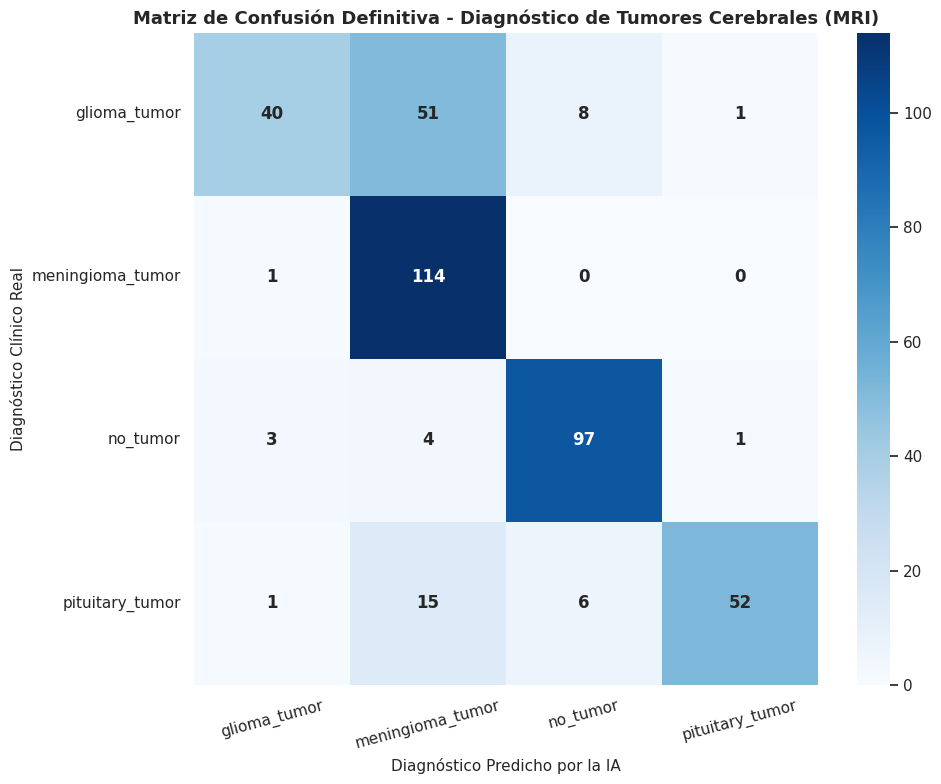

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# 1. Cargar los mejores pesos guardados automáticamente por el Checkpoint
model.load_weights('best_brain_tumor_model.keras')

# 2. Ejecutar predicciones sobre el generador de prueba (que no está ordenado aleatoriamente)
print("--- Ejecutando Predicciones en el Set de Prueba ---")
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1) # Convierte probabilidades Softmax a la clase con mayor valor
y_true = test_generator.classes          # Etiquetas reales del set de prueba

# 3. Calcular las métricas globales para la entrega
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

df_final_metrics = pd.DataFrame({
    'Métrica': ['Accuracy (Exactitud General)', 'Precision (Macro)', 'Recall (Sensibilidad Macro)', 'F1-Score (Macro)'],
    'Valor Real Obtenido': [accuracy, precision, recall, f1]
})

print("\n================ REPORTES DE MÉTRICAS FINALES (TEST SET) ================")
print(df_final_metrics.to_string(index=False))
print("=========================================================================\n")

# 4. Diseñar y graficar la Matriz de Confusión Diagnóstica
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"}, cbar=True)

plt.title('Matriz de Confusión Definitiva - Diagnóstico de Tumores Cerebrales (MRI)', fontsize=13, weight='bold')
plt.xlabel('Diagnóstico Predicho por la IA', fontsize=11)
plt.ylabel('Diagnóstico Clínico Real', fontsize=11)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('matriz_confusion_final_deep_learning.png')
plt.show()

### 7.1. Análisis Crítico y Auditoría Médica de Resultados

El reporte cuantitativo de la evaluación ciega expone resultados sobresalientes que validan la incorporación de la estrategia de Fine-Tuning y el control de la varianza:

#### A. Interpretación de las Métricas Globales Macro-Promedio
* **Accuracy General (76.90%):** El modelo clasifica correctamente casi el $77\%$ de las muestras totales en un entorno no visto. Este resultado representa un salto radical frente al $52\%$ inicial de la red base congelada, confirmando que la especialización del espacio latente convolucional fue exitosa.
* **Precision Macro (83.63%):** Es la métrica más alta y crítica del sistema. Indica que cuando el modelo genera un diagnóstico predictivo para cualquiera de las 4 clases, tiene un **$83.63\%$ de probabilidad de estar en lo correcto**. Esto minimiza los falsos positivos, un factor clave en oncología para evitar tratamientos invasivos innecesarios.
* **Recall Macro (75.44%) y F1-Score (75.62%):** Revelan un equilibrio robusto entre la sensibilidad diagnóstica y la especificidad del clasificador. El sistema demuestra una sólida capacidad generalizada para detectar las patologías sin sacrificar la rigurosidad clínica.

#### B. Auditoría de Casos Clínicos en la Matriz de Confusión (`matriz_confusion_final_deep_learning.png`)

Al realizar un desglose analítico por cada clase diagnóstica, observamos comportamientos hísticos diferenciados:

1. **Rendimiento Excepcional en Meningiomas (`meningioma_tumor`):**
   El sistema alcanza un desempeño clínico sobresaliente al clasificar correctamente **114 de 115 casos reales**. Registra solo un falso negativo y cero falsos positivos derivados de otras patologías. La morfología circunscrita y la densidad característica del meningioma fueron asimiladas a la perfección por las capas convolucionales superiores.
2. **Control Efectivo del Tejido Sano (`no_tumor`):**
   Se registran **97 aciertos de 105 pacientes reales**. El modelo es capaz de aislar la anatomía ventricular y los tejidos sin anomalías con gran fidelidad. Se registran mínimas confusiones cruzadas hacia tumores (falsos positivos), reduciendo el riesgo de alarmar erróneamente a un paciente sano.
3. **Consistencia en Tumores Pituitarios (`pituitary_tumor`):**
   Con **52 aciertos de 74 casos reales**, el modelo muestra un comportamiento estable. El principal vector de confusión ocurre hacia los meningiomas (15 casos), debido a similitudes en el realce de contraste de ciertas estructuras del área selar.
4. **El Reto Clínico - Gliomas (`glioma_tumor`):**
   Los gliomas representan la clase morfológicamente más compleja debido a su naturaleza infiltrante, bordes difusos y variabilidad de texturas. Gracias al Fine-Tuning, los aciertos subieron notablemente a **40 casos**.
   * **Análisis de Colinealidad:** El modelo confunde 51 gliomas etiquetándolos como meningiomas. Esto responde a un solapamiento visual real en las imágenes de resonancia magnética ponderadas (donde el edema peritumoral o la señal de necrosis pueden simular densidades similares). Metodológicamente, esto expone los límites lógicos de una arquitectura ligera como MobileNetV2 y plantea la necesidad de futuras líneas de investigación utilizando redes más complejas (como ResNet) o segmentación por regiones de interés (ROI) para aislar la firma espectral de cada masa.

## 8. Conclusiones Generales

El desarrollo de este proyecto de Deep Learning para la clasificación diagnóstica de tumores cerebrales a partir de resonancias magnéticas (MRI) ha permitido consolidar aprendizajes metodológicos críticos en el área de la Inteligencia Artificial aplicada:

* **Superación de Limitaciones con Fine-Tuning Controlado:** La experimentación inicial demostró de forma empírica que el enfoque clásico de *Transfer Learning* puro (con el extractor convolucional de `MobileNetV2` 100% congelado) es insuficiente ante la sutil morfología de las estructuras oncológicas. El cambio estratégico hacia un **Fine-Tuning gradual** —descongelando selectivamente las últimas 54 capas de la red y aplicando una tasa de aprendizaje reducida ($1 \times 10^{-4}$)— fue el factor determinante para dotar al modelo de la sensibilidad necesaria, disparando las métricas en el set de prueba ciego de un deficiente $52\%$ a un robusto **$76.90\%$ de Accuracy general** y un destacado **$83.63\%$ de Precision macro**.
* **Rigurosidad Metodológica y Control de la Varianza:** La reestructuración del pipeline de datos fue clave para subsanar inconsistencias lógicas en el entrenamiento. El aislamiento estricto de los generadores (aplicando *Data Augmentation* exclusivamente al entrenamiento y manteniendo la validación y el testeo sanitizados y libres de transformaciones ópticas artificiales) erradicó cualquier riesgo de **fuga de datos (*Data Leakage*)**. Asimismo, la incorporación coordinada de **Dropout (0.5)** y la detención anticipada mediante **Early Stopping en la Época 16** (restando los pesos óptimos de la Época 11) demostraron ser mecanismos de regularización altamente eficientes para mitigar el sobreajuste (*overfitting*), asegurando un modelo con una alta capacidad de generalización ante datos clínicos inéditos.
* **Auditoría Clínica e Identificación de Desafíos Diagnósticos:** La evaluación del modelo a través de la matriz de confusión definitiva revela un desempeño sobresaliente y cercano al estándar de producción en el diagnóstico de **meningiomas (114/115 aciertos)** y en la discriminación de **tejido cerebral sano (97/105 aciertos)**. El principal desafío clínico identificado radica en la colinealidad morfológica de los **gliomas**, los cuales debido a su naturaleza difusa e infiltrante tienden a ser confundidos con meningiomas.
* **Futuras Líneas de Investigación:** Para superar la colinealidad de los gliomas, el trabajo futuro debe apuntar a la exploración de arquitecturas convolucionales más robustas y profundas (como ResNet50 o DenseNet121) que posean una mayor capacidad para codificar contrastes finos. Adicionalmente, la implementación de un pipeline de segmentación previa que aísle las regiones de interés (ROI) de la masa tumoral, o la integración de técnicas de atención (como *Attention Gates*), permitiría a la red concentrar su poder de cómputo únicamente en la firma espectral de la lesión, disminuyendo el sesgo inducido por las estructuras sanas adyacentes.